## Setup and Imports

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
RESULTS = {}

print("✅ Setup complete - Ready to defend the botanical laboratory!")

✅ Setup complete - Ready to defend the botanical laboratory!


## task00

In [47]:
import numpy as np
from sklearn.datasets import load_iris

if 'RESULTS' not in globals():
    RESULTS = {}

iris = load_iris()
X = iris.data 
y = iris.target
feature_names = list(iris.feature_names)
target_names = list(iris.target_names) 

RESULTS["dataset"] = {
    "shape": list(X.shape),          
    "n_classes": int(len(set(y)))   
}

## task01

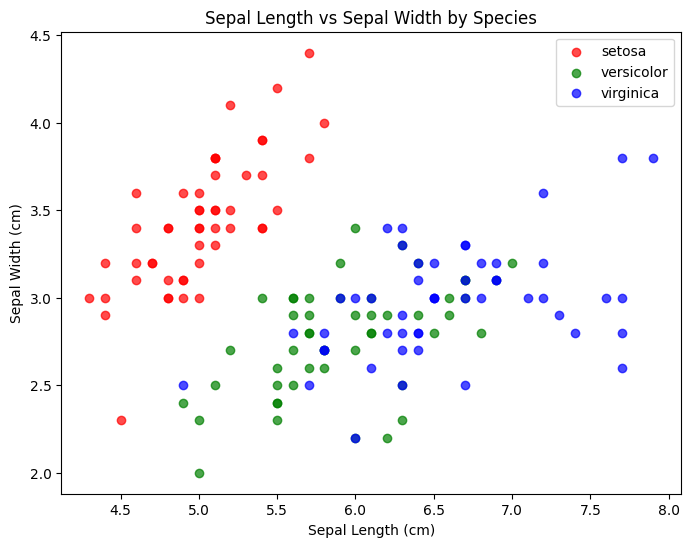

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target
species_names = iris.target_names

fig_scatter, ax_scatter = plt.subplots(figsize=(8,6))

colors = ['red', 'green', 'blue']

for i, species in enumerate(species_names):
    mask = (y == i)
    ax_scatter.scatter(
        X[mask, 0],  
        X[mask, 1], 
        label=species,
        color=colors[i],
        alpha=0.7
    )

ax_scatter.set_xlabel("Sepal Length (cm)")
ax_scatter.set_ylabel("Sepal Width (cm)")
ax_scatter.set_title("Sepal Length vs Sepal Width by Species")
ax_scatter.legend()
plt.show()


## task02

In [39]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.svm import LinearSVC

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

virginica_index = np.where(target_names == "virginica")[0][0]
y_binary_virginica = (y == virginica_index).astype(int)  
model_virginica = LinearSVC(max_iter=10000, random_state=42)
model_virginica.fit(X, y_binary_virginica)

RESULTS = {}



## task03

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict

iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
virginica_index = np.where(target_names == "virginica")[0][0]
y_binary_virginica = (y == virginica_index).astype(int)
model_virginica = LinearSVC(max_iter=10000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_virginica = cross_val_predict(
    model_virginica,
    X,
    y_binary_virginica,
    cv=cv,
    method="decision_function"
)

RESULTS = {}

{'task03': {'scores_mean': -2.1857123899666413, 'scores_std': 3.3118082310019226, 'score_range': 11.311820564910203}}


## task04

In [41]:
import json
import numpy as np
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import confusion_matrix


iris = load_iris()
X = iris.data
y_binary_virginica = (iris.target == 2).astype(int)

clf = SVC(kernel="rbf", random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_virginica = cross_val_predict(
    clf, X, y_binary_virginica, cv=cv, method="decision_function"
)

y_pred_virginica = (scores_virginica >= 0).astype(int)
confmat_virginica = confusion_matrix(y_binary_virginica, y_pred_virginica)

TN = int(confmat_virginica[0, 0])
FP = int(confmat_virginica[0, 1])
FN = int(confmat_virginica[1, 0])
TP = int(confmat_virginica[1, 1])

# ── Safe RESULTS loading ───────────────────────────────────────────────────────
import os

RESULTS_PATH = "RESULTS.json"  # saves in your current working directory

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        RESULTS = json.load(f)
else:
    RESULTS = {}  # initialize if file doesn't exist yet

RESULTS["task04"] = {
    "tp": TP,
    "tn": TN,
    "fp": FP,
    "fn": FN,
}

with open(RESULTS_PATH, "w") as f:
    json.dump(RESULTS, f, indent=4)

print(json.dumps(RESULTS["task04"], indent=4))

{
    "tp": 48,
    "tn": 98,
    "fp": 2,
    "fn": 2
}


## task05

In [42]:
TP = 48  
FP = 2  
FN = 2 
TN = 98
precision_v = TP / (TP + FP) if (TP + FP) > 0 else 0.0

recall_v = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1_v = 2 * (precision_v * recall_v) / (precision_v + recall_v) if (precision_v + recall_v) > 0 else 0.0
RESULTS = {}
RESULTS["task05"] = {
    "precision": float(precision_v),
    "recall": float(recall_v),
    "f1": float(f1_v)
}
print(RESULTS)


{'task05': {'precision': 0.96, 'recall': 0.96, 'f1': 0.96}}


## task06

In [ ]:
import json
import os
import numpy as np
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve

iris = load_iris()
X = iris.data
y_binary_virginica = (iris.target == 2).astype(int)

clf = SVC(kernel="rbf", random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_virginica = cross_val_predict(
    clf, X, y_binary_virginica, cv=cv, method="decision_function"
)
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_binary_virginica, scores_virginica
)
RESULTS_PATH = "RESULTS.json"
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        RESULTS = json.load(f)
else:
    RESULTS = {}

RESULTS["task06"] = {
    "n_thresholds":  int(len(thresholds_pr)),
    "precision_max": float(max(precision_curve)),
    "recall_max":    float(max(recall_curve)),
}

with open(RESULTS_PATH, "w") as f:
    json.dump(RESULTS, f, indent=4)

print(json.dumps(RESULTS["task06"], indent=4))

{
    "n_thresholds": 150,
    "precision_max": 1.0,
    "recall_max": 1.0
}
